Load Data

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("./data/diabetes_risk_prediction_dataset.csv")
df = df.drop(columns=['Patient_ID'])

Analyze Data

Numerical Data

In [32]:
num_cols = df.select_dtypes(include='number').columns.tolist()

num_cols

['Age',
 'Height_cm',
 'Weight_kg',
 'BMI',
 'Waist_Circumference_cm',
 'Blood_Glucose',
 'HbA1c',
 'Fasting_Blood_Sugar',
 'Insulin_Level',
 'Blood_Pressure_Systolic',
 'Blood_Pressure_Diastolic',
 'Total_Cholesterol',
 'HDL',
 'LDL',
 'Triglycerides',
 'Heart_Rate',
 'Exercise_Hours_Per_Week',
 'Daily_Walking_Minutes',
 'Sleep_Hours',
 'Daily_Water_Intake_L',
 'Diabetes_Risk_Score']

In [33]:
df.groupby("Diabetes_Risk")[num_cols].mean()

,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
Diabetes_Risk,,,,,,,,,,,,,,,,,,,,,
High,56.526924,169.353825,89.613335,31.918181,99.905523,160.074076,8.858595,152.775777,23.435687,142.251496,...,223.374637,57.396940,134.896539,229.569019,85.129861,5.017951,89.807673,6.439520,3.006441,81.409122
Low,38.813305,173.662556,75.677098,25.597447,100.846170,159.011983,5.673451,88.441915,23.051915,127.976596,...,200.408874,58.678214,135.038445,229.466955,85.361702,5.033857,91.203084,6.775110,2.938723,29.236170
Moderate,46.890827,171.758392,81.769120,28.305635,100.084950,159.459795,7.542885,115.813017,23.608232,134.729690,...,211.824097,57.252833,135.347436,229.473049,85.099791,5.015484,90.242147,6.664362,2.979532,54.838912


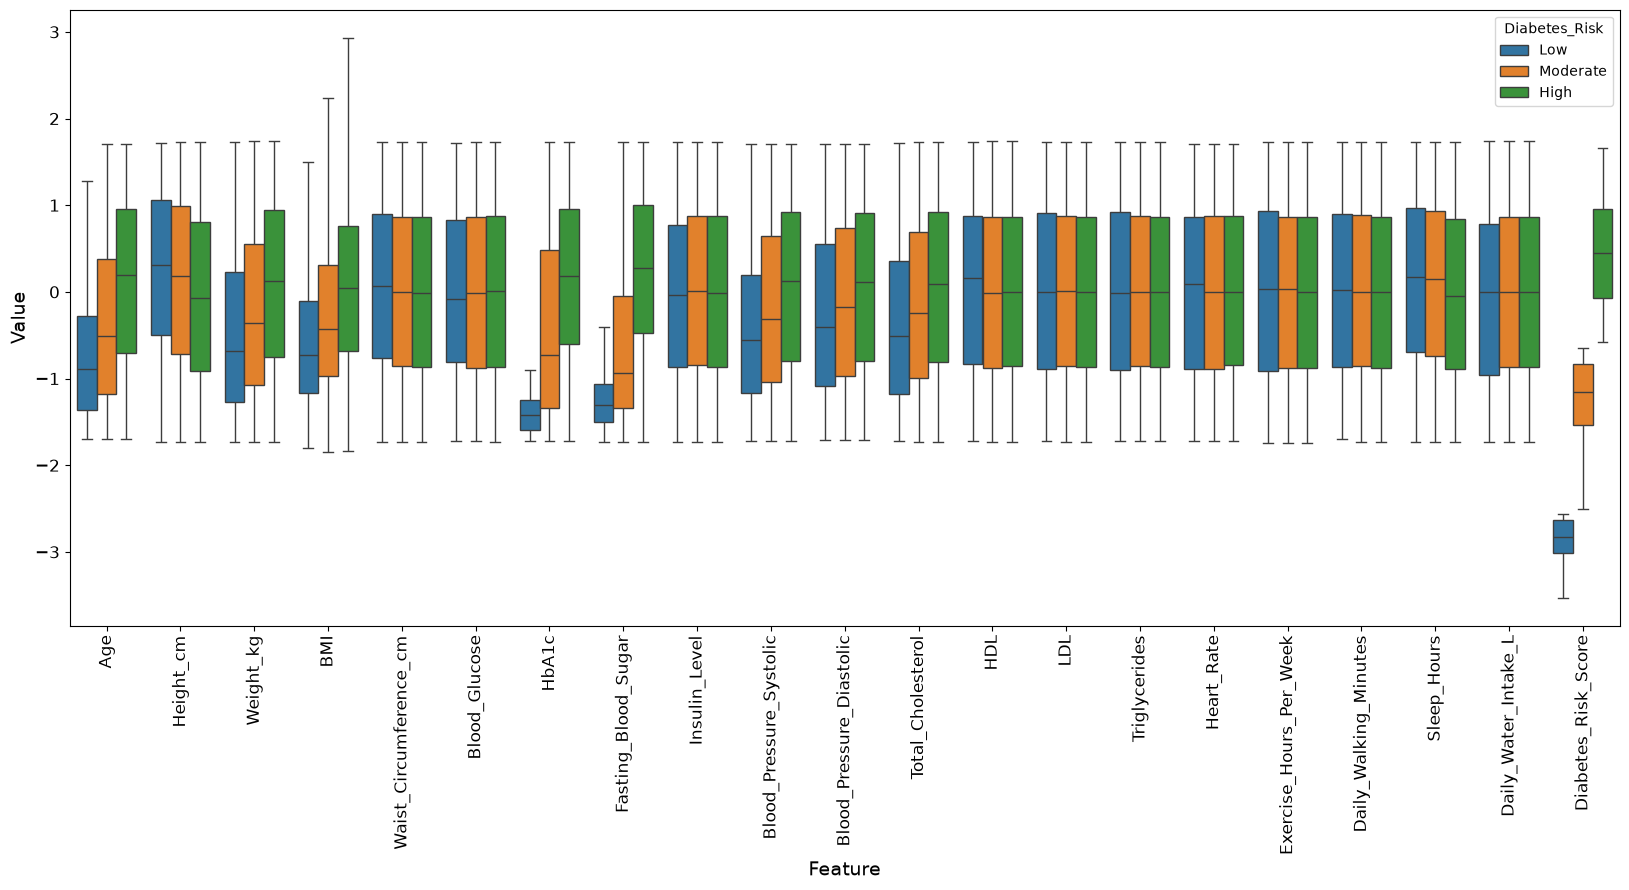

In [42]:
df[num_cols] = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()
df_melted = df.melt(id_vars="Diabetes_Risk", value_vars=num_cols, var_name="Feature", value_name="Value")

plt.figure(figsize=(20, 8))

sns.boxplot(data=df_melted, x="Feature", y="Value", hue="Diabetes_Risk", hue_order=["Low", "Moderate", "High"], showfliers=False)

plt.xlabel("Feature", fontsize=14)
plt.ylabel("Value", fontsize=14)

plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Prioritize features where there are larger separations in distribution between low, moderate, and high diabetes risk

In [35]:
cols = ["Age", "Height_cm", "Weight_kg", "Blood_Glucose", "Diabetes_Risk" ]